#StatusBoost: Multi-Class Status Prediction using CatBoost

This notebook implements a structured machine learning pipeline for predicting
status categories using tabular data. The model leverages CatBoost for efficient
handling of categorical features and uses early stopping for better generalization.

Key Features:
- Feature engineering (Age → AgeYears)
- Native categorical processing
- Train/validation split
- Probability-based predictions

Author: Abdulla Rustamov


In [49]:
!pip install -q catboost

import os
import zipfile
import warnings
import numpy as np
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")

In [50]:
SEED = 42

TRAIN_PATH = "/content/train.csv"
TEST_PATH = "/content/test.csv"
SAMPLE_SUB_PATH = "/content/sample_submission.csv"

OUT_PATH = "/content/submission.csv"

In [51]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("Train:", train.shape)
print("Test :", test.shape)

Train: (15000, 20)
Test : (10000, 19)


In [52]:
id_col = "id"
target_col = "Status"

prob_cols = [c for c in sample_sub.columns if c != id_col]
classes = [c.replace("Status_", "") for c in prob_cols]

print("Classes:", classes)

Classes: ['C', 'CL', 'D']


In [53]:
for df in (train, test):
    df.columns = [c.strip() for c in df.columns]

    if "Age" in df.columns:
        df["AgeYears"] = pd.to_numeric(df["Age"], errors="coerce") / 365.25

train[target_col] = train[target_col].astype(str).str.strip()

train = train[train[target_col].isin(classes)].copy()

print(train[target_col].value_counts())

Status
C     10053
D      4565
CL      381
Name: count, dtype: int64


In [54]:
candidate_cat_cols = [
    "Drug", "Sex", "Ascites", "Hepatomegaly", "Spiders", "Edema"
]

cat_cols = [c for c in candidate_cat_cols if c in train.columns]

for c in cat_cols:
    train[c] = train[c].fillna("Missing").astype(str).str.strip()
    test[c] = test[c].fillna("Missing").astype(str).str.strip()

print("Categorical:", cat_cols)

Categorical: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']


In [55]:
# Separate features and target variable
X = train.drop(columns=[id_col, target_col], errors="ignore")
y = train[target_col]

# Prepare test features
X_test = test.drop(columns=[id_col], errors="ignore")

# Remove redundant Age column after creating AgeYears
if "AgeYears" in X.columns and "Age" in X.columns:
    X.drop(columns=["Age"], inplace=True)

if "AgeYears" in X_test.columns and "Age" in X_test.columns:
    X_test.drop(columns=["Age"], inplace=True)

# Convert numerical columns to numeric type
for c in X.columns:
    if c not in cat_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")

for c in X_test.columns:
    if c not in cat_cols:
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce")

# Ensure test set has the same columns as training set
X_test = X_test.reindex(columns=X.columns, fill_value=np.nan)

print(X.shape, X_test.shape)

(14999, 18) (10000, 18)


In [56]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [57]:
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
val_pool = Pool(X_val, y_val, cat_features=cat_cols)
test_pool = Pool(X_test, cat_features=cat_cols)

In [58]:
# Get class labels in sorted order
class_labels = np.unique(y_train)

# Compute balanced weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=y_train
)

# Convert to list for CatBoost
class_weights = list(weights)

print("Class labels:", class_labels)
print("Class weights:", class_weights)

Class labels: ['C' 'CL' 'D']
Class weights: [np.float64(0.49734726021719305), np.float64(13.113661202185792), np.float64(1.0951989777290982)]


In [67]:
class_weights = [1.0, 5.0, 1.2]

model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=10,
    random_seed=SEED,
    early_stopping_rounds=200,
    class_weights=class_weights,
    verbose=200
)

In [68]:
model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

0:	learn: 1.0730838	test: 1.0729786	best: 1.0729786 (0)	total: 146ms	remaining: 4m 52s
200:	learn: 0.5293069	test: 0.5398204	best: 0.5398204 (200)	total: 10.1s	remaining: 1m 30s
400:	learn: 0.4838061	test: 0.5136966	best: 0.5136966 (400)	total: 18.6s	remaining: 1m 14s
600:	learn: 0.4494542	test: 0.5024918	best: 0.5024868 (599)	total: 27s	remaining: 1m 2s
800:	learn: 0.4254658	test: 0.4975545	best: 0.4975038 (799)	total: 36s	remaining: 53.8s
1000:	learn: 0.4031704	test: 0.4945394	best: 0.4945109 (999)	total: 44.9s	remaining: 44.8s
1200:	learn: 0.3849877	test: 0.4930782	best: 0.4928375 (1157)	total: 53.7s	remaining: 35.8s
1400:	learn: 0.3677694	test: 0.4908825	best: 0.4908758 (1395)	total: 1m 2s	remaining: 26.6s
1600:	learn: 0.3533112	test: 0.4911465	best: 0.4906216 (1425)	total: 1m 11s	remaining: 17.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.4906215787
bestIteration = 1425

Shrink model to first 1426 iterations.


CatBoostClassifier(class_weights=[1.0, 5.0, 1.2], depth=6, early_stopping_rounds=200, eval_metric='MultiClass', iterations=2000, l2_leaf_reg=10, learning_rate=0.03, loss_function='MultiClass', random_seed=42, verbose=200)

In [70]:
test_proba = model.predict_proba(test_pool)
model_classes = list(model.classes_)

In [71]:
proba_df = pd.DataFrame(
    test_proba,
    columns=[f"Status_{c}" for c in model_classes]
)

for col in prob_cols:
    if col not in proba_df.columns:
        proba_df[col] = 0.0

proba_df = proba_df[prob_cols]

In [72]:
submission = pd.DataFrame({id_col: sample_sub[id_col]})
submission = pd.concat([submission, proba_df], axis=1)

submission.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
submission.head()

Saved: /content/submission.csv


,id,Status_C,Status_CL,Status_D
0,15000,0.380619,0.019053,0.600328
1,15001,0.819322,0.029032,0.151646
2,15002,0.716606,0.013740,0.269655
3,15003,0.972538,0.005814,0.021648
4,15004,0.226547,0.296432,0.477020


In [73]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
7,Bilirubin,14.955144
17,AgeYears,13.338527
0,N_Days,12.389253
15,Prothrombin,11.582220
14,Platelets,10.242687
9,Albumin,5.334968
10,Copper,4.943852
16,Stage,4.252264
12,SGOT,3.988189
4,Hepatomegaly,3.524162


In [74]:
# Predict on validation set
val_pred = model.predict(val_pool)

# Accuracy
acc = accuracy_score(y_val, val_pred)

# F1 score (macro)
f1 = f1_score(y_val, val_pred, average="macro")

print("Validation Accuracy:", acc)
print("Validation F1 (macro):", f1)

print("\nClassification Report:")
print(classification_report(y_val, val_pred))

Validation Accuracy: 0.846
Validation F1 (macro): 0.6910817917670263

Classification Report:
              precision    recall  f1-score   support

           C       0.88      0.91      0.89      2011
          CL       0.45      0.38      0.41        76
           D       0.80      0.74      0.77       913

    accuracy                           0.85      3000
   macro avg       0.71      0.68      0.69      3000
weighted avg       0.84      0.85      0.84      3000



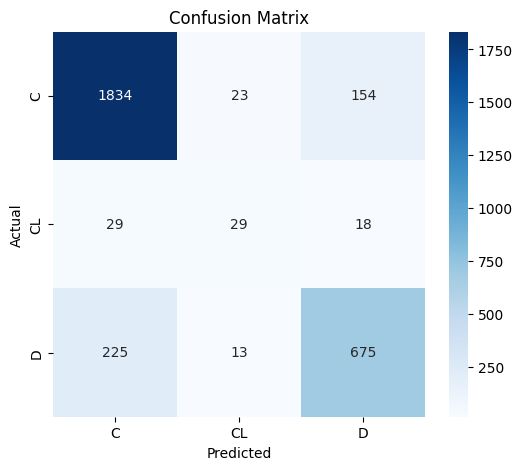

In [75]:
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()